# Movie Rating Prediction with Python — A Data Analytics & ML Approach

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# Load Dataset

In [8]:
df = pd.read_csv("/kaggle/input/datasets/adrianmcmahon/imdb-india-movies/IMDb Movies India.csv", encoding="latin1")
df.head()


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


# Data Cleaning & Preprocessing

In [9]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [10]:
# Remove rows where Rating is missing
df = df.dropna(subset=["Rating"])


In [11]:
# Convert Votes to numeric
df["Votes"] = df["Votes"].str.replace(",", "")
df["Votes"] = pd.to_numeric(df["Votes"], errors="coerce")


In [12]:
# Convert Duration to numeric
df["Duration"] = df["Duration"].str.replace(" min", "")
df["Duration"] = pd.to_numeric(df["Duration"], errors="coerce")

# Drop rows with major missing values
df = df.dropna()

df.shape

(5659, 10)

# Exploratory Data Analysis (EDA)

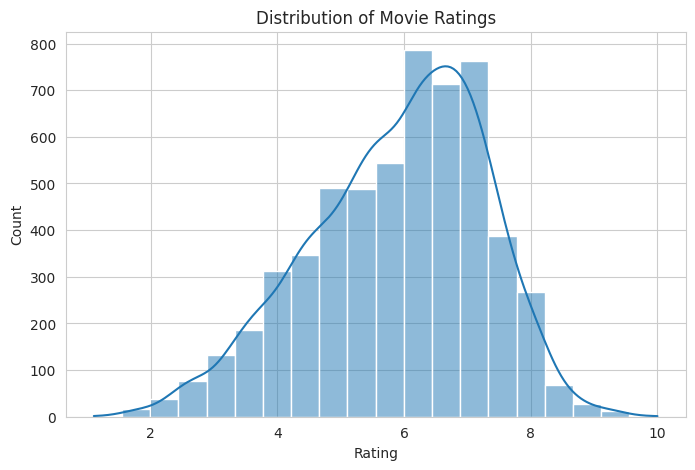

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["Rating"], bins=20, kde=True)
plt.title("Distribution of Movie Ratings")
plt.show()

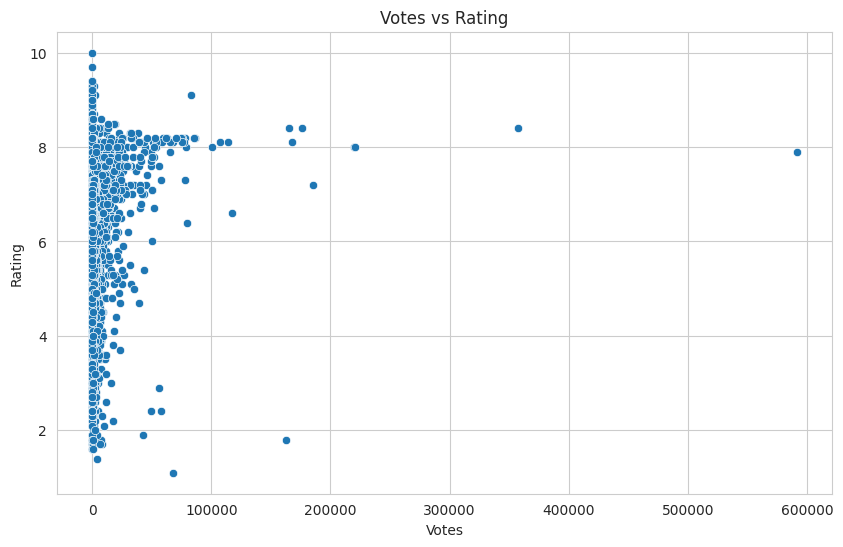

In [15]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="Votes", y="Rating", data=df)
plt.title("Votes vs Rating")
plt.show()


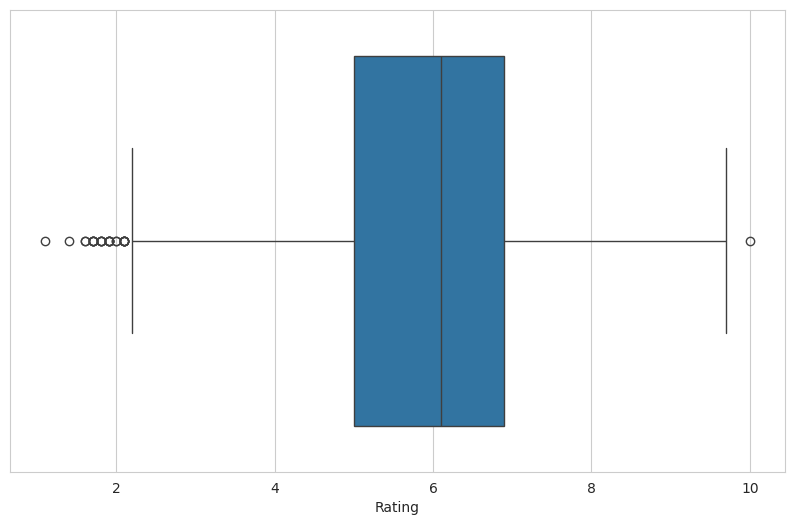

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Rating", data=df)
plt.show()

# Duration Distribution

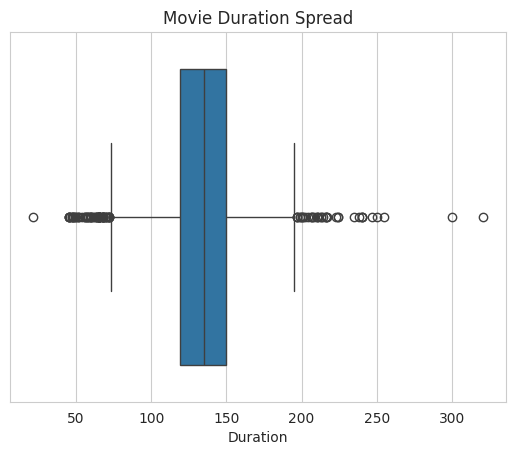

In [17]:
sns.boxplot(x=df['Duration'])
plt.title("Movie Duration Spread")
plt.show()

# Time-Based Trend Analysis
Movies Released Per Year

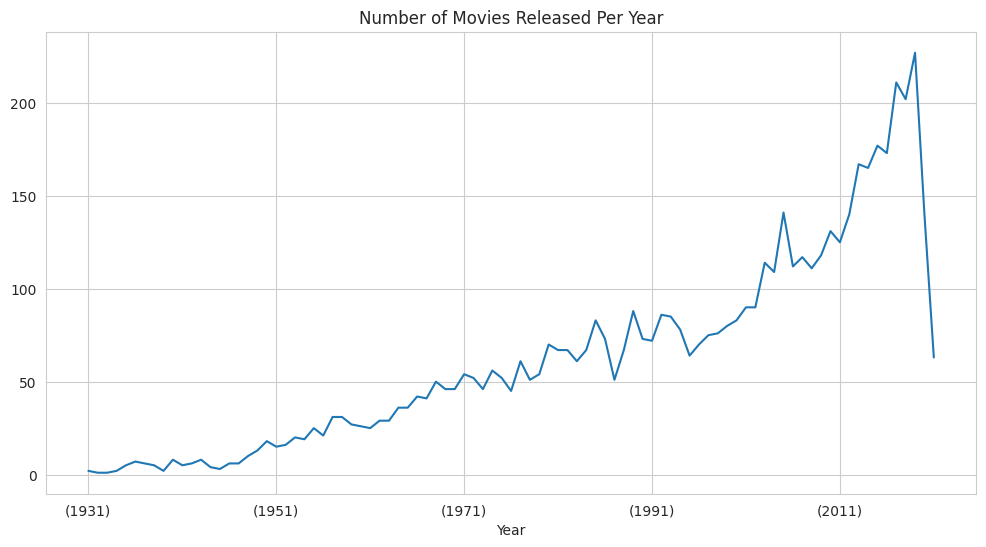

In [18]:
movies_per_year = df.groupby('Year').size()

plt.figure(figsize=(12,6))
movies_per_year.plot()
plt.title("Number of Movies Released Per Year")
plt.show()


# Genre Analysis
Split and Explode Genres

In [19]:
df['Genre'] = df['Genre'].str.split(', ')
df_exploded = df.explode('Genre')


# Most Popular Genres

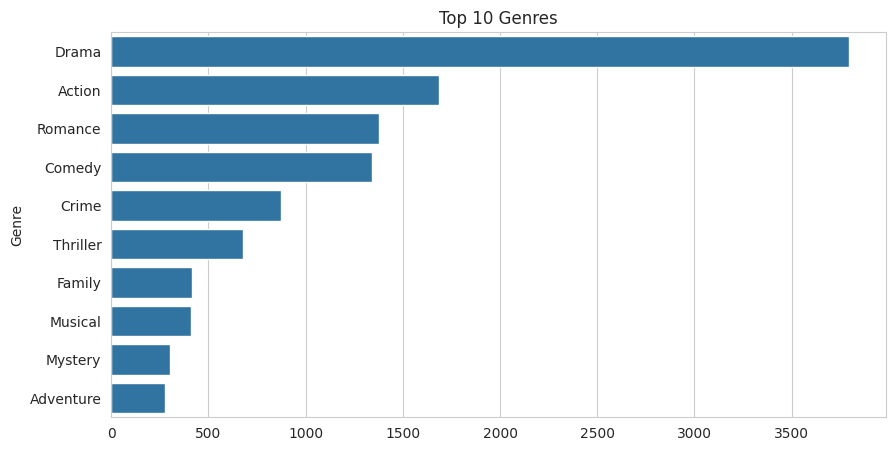

In [20]:
top_genres = df_exploded['Genre'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres")
plt.show()

# Average Rating per Genre

In [21]:
genre_rating = df_exploded.groupby('Genre')['Rating'].mean().sort_values(ascending=False)

genre_rating.head(10)


Genre
News           8.000000
Documentary    7.608333
History        6.905051
Biography      6.737391
Sport          6.515000
Family         6.323317
Musical        6.246845
Animation      6.072500
Music          6.071698
Drama          6.056744
Name: Rating, dtype: float64

# Director & Actor Analysis
 Top Directors by Number of Movies

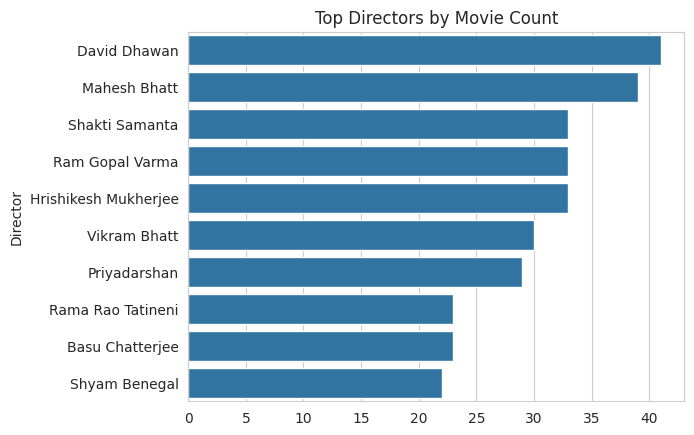

In [23]:
top_directors = df['Director'].value_counts().head(10)

sns.barplot(x=top_directors.values, y=top_directors.index)
plt.title("Top Directors by Movie Count")
plt.show()


# Highest Rated Directors (With Minimum 5 Movies)

In [24]:
director_stats = df.groupby('Director').agg({
    'Rating':'mean',
    'Name':'count'
})

director_stats = director_stats[director_stats['Name'] >= 5]
director_stats.sort_values('Rating', ascending=False).head(10)


,Rating,Name
Director,,
Rajkumar Hirani,8.060000,5
Gulzar,7.552941,17
Tapan Sinha,7.533333,6
Vikramaditya Motwane,7.500000,5
Neeraj Pandey,7.460000,5
Sai Paranjape,7.460000,5
Kidar Nath Sharma,7.460000,5
Guru Dutt,7.428571,7
Anurag Kashyap,7.400000,13


# Votes vs Rating Correlation

In [27]:
df['Votes'] = pd.to_numeric(
    df['Votes'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)



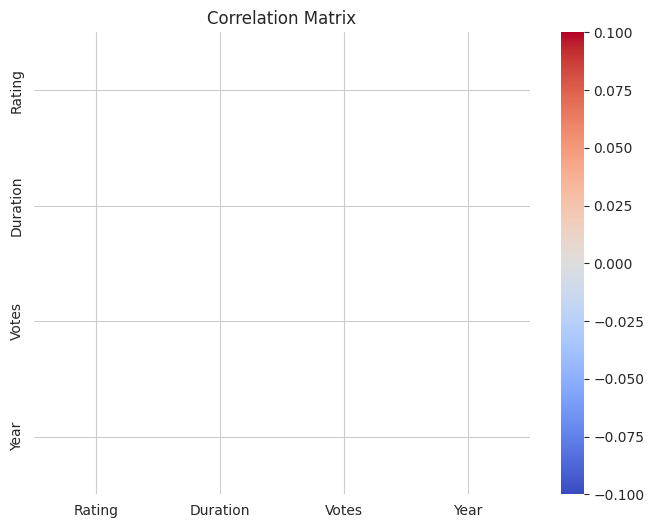

In [29]:
cols = ['Rating','Duration','Votes','Year']

corr_df = df[cols].apply(pd.to_numeric, errors='coerce').dropna()

plt.figure(figsize=(8,6))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


# Votes vs Rating Scatter Plot

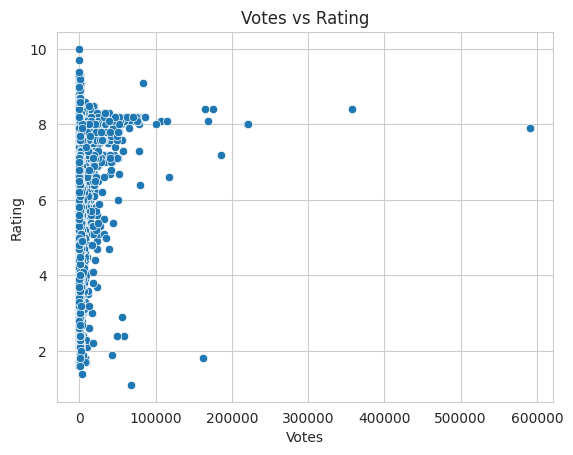

In [30]:
sns.scatterplot(x='Votes', y='Rating', data=df)
plt.title("Votes vs Rating")
plt.show()


# Feature Engineering

In [31]:
# Select relevant features
features = ["Year", "Duration", "Votes", "Genre", "Director"]
target = "Rating"

X = df[features]
y = df[target]

# Categorical and numerical columns
categorical_cols = ["Genre", "Director"]
numerical_cols = ["Year", "Duration", "Votes"]

# Preprocessing Pipeline

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# Train-Test Split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model Training (Multiple Models)

# Linear Regression

In [38]:

# Remove parentheses from Year
df["Year"] = df["Year"].str.replace("(", "", regex=False)
df["Year"] = df["Year"].str.replace(")", "", regex=False)

# Convert to numeric
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")


In [42]:
df["Votes"] = (
    df["Votes"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Votes"] = pd.to_numeric(df["Votes"], errors="coerce")



In [43]:
print(df["Votes"].dtype)


int64


In [44]:
print(df["Votes"].unique()[:20])


[   8   35  827 1086  326   11   17   59  983  512 6619  162   72   63
   26 6329 1002   15 1235   10]


In [45]:
df = df.dropna(subset=["Votes"])


In [48]:
# Extract only 4-digit year using regex (BEST METHOD)

df["Year"] = (
    df["Year"]
    .astype(str)
    .str.extract(r"(\d{4})")   # extract only 4 digit year
)

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")


In [49]:
df["Duration"] = (
    df["Duration"]
    .astype(str)
    .str.replace(" min", "", regex=False)
    .str.strip()
)

df["Duration"] = pd.to_numeric(df["Duration"], errors="coerce")


In [50]:
df["Votes"] = (
    df["Votes"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Votes"] = pd.to_numeric(df["Votes"], errors="coerce")


In [51]:
df = df.dropna(subset=["Year", "Duration", "Votes", "Rating"])


In [52]:
print(df[["Year","Duration","Votes"]].dtypes)


Year          int64
Duration    float64
Votes         int64
dtype: object


In [53]:
features = ["Year", "Duration", "Votes", "Genre", "Director"]
target = "Rating"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [55]:
print(X_train.head())
print(X_train.dtypes)



       Year  Duration  Votes                     Genre         Director
9424   2016     143.0     13                   [Drama]   Hemnt Praddeep
12009  1942     153.0     30                   [Drama]     Mehboob Khan
4316   1989     147.0    455  [Drama, Musical, Family]     K. Viswanath
6897   1961     139.0    467  [Comedy, Drama, Musical]  Subodh Mukherji
2338   2012      74.0     22                   [Drama]     Ashtar Sayed
Year          int64
Duration    float64
Votes         int64
Genre        object
Director     object
dtype: object


In [60]:
def predict_rating(year, duration, votes, genre, director):
    input_data = pd.DataFrame({
        "Year": [year],
        "Duration": [duration],
        "Votes": [votes],
        "Genre": [genre],
        "Director": [director]
    })
    
    model = joblib.load("models/best_model.pkl")
    prediction = model.predict(input_data)
    
    return prediction[0]
